# 📊 Student Performance Analysis using Python

## Project Overview

This project performs Exploratory Data Analysis (EDA), Statistical Analysis, and Machine Learning on student performance data to understand the factors affecting academic success.

The goal is to discover meaningful insights, identify important trends, and build predictive models that estimate student performance.

# 1️⃣ Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

# 2️⃣ Load Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [ ]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# 3️⃣ Data Understanding

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.sample(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
434,male,group C,some high school,standard,none,73,66,66
154,male,group D,some high school,standard,none,62,67,61
609,female,group B,associate's degree,standard,none,58,63,65
998,female,group D,some college,standard,completed,68,78,77
240,male,group D,high school,free/reduced,completed,73,68,66
756,male,group D,some college,standard,none,55,58,52
491,female,group C,associate's degree,standard,none,64,64,70
691,female,group E,associate's degree,free/reduced,none,73,76,78
399,male,group D,some high school,standard,none,60,59,54
444,male,group A,some high school,free/reduced,none,79,82,73


### Dataset Summary

- Number of observations:
- Number of features:
- Numerical Columns:
- Categorical Columns:

# 4️⃣ Data Cleaning

Data cleaning ensures the dataset is accurate, consistent, and ready for analysis. In this section, we will:
- Check for missing values
- Identify duplicate records
- Rename columns for better readability
- Verify data types
- Validate categorical values

In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("/", "_")
)

df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [ ]:
df.dtypes

,0
gender,object
race_ethnicity,object
parental_level_of_education,object
lunch,object
test_preparation_course,object
math_score,int64
reading_score,int64
writing_score,int64


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


gender
['female' 'male']

race_ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']

parental_level_of_education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch
['standard' 'free/reduced']

test_preparation_course
['none' 'completed']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### Data Cleaning Summary

- No missing values were found.
- No duplicate records were identified.
- Column names were standardized for consistency.
- Data types were verified and required no changes.
- The dataset is clean and ready for feature engineering and exploratory analysis.

# 5️⃣ Feature Engineering

Feature engineering involves creating new variables from the existing data to improve analysis and predictive modeling.

In this section we will create:

- Total Score
- Average Score
- Percentage
- Grade
- Performance Category
- Pass / Fail Status

In [ ]:
df["total_score"] = (
    df["math_score"] +
    df["reading_score"] +
    df["writing_score"]
)

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [ ]:
df["average_score"] = df["total_score"] / 3

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
df["percentage"] = (df["total_score"] / 300) * 100

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,percentage
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333,76.333333


In [ ]:
def assign_grade(score):

    if score >= 90:
        return "A+"

    elif score >= 80:
        return "A"

    elif score >= 70:
        return "B"

    elif score >= 60:
        return "C"

    elif score >= 50:
        return "D"

    elif score >= 40:
        return "E"

    else:
        return "F"

df["grade"] = df["percentage"].apply(assign_grade)

In [ ]:
df["result"] = np.where(df["percentage"] >= 40,
                        "Pass",
                        "Fail")

In [ ]:
def performance(score):

    if score >= 85:
        return "Excellent"

    elif score >= 70:
        return "Good"

    elif score >= 50:
        return "Average"

    else:
        return "Poor"

df["performance"] = df["percentage"].apply(performance)

In [ ]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,percentage,grade,result,performance
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,72.666667,B,Pass,Good
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,82.333333,A,Pass,Good
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,92.666667,A+,Pass,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,49.333333,E,Pass,Poor
4,male,group C,some college,standard,none,76,78,75,229,76.333333,76.333333,B,Pass,Good


In [ ]:
df.describe()

,math_score,reading_score,writing_score,total_score,average_score,percentage
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race_ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test_preparation_course      1000 non-null   object 
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
 10  percentage                   1000 non-null   float64
 11  grade                        1000 non-null   object 
 12  result                       1000 non-null   object 
 13  performance        

## Feature Engineering Summary

The following features were created to enhance the dataset:

- Total Score
- Average Score
- Percentage
- Grade
- Result (Pass/Fail)
- Performance Category

These engineered features provide a more comprehensive understanding of student performance and will support deeper exploratory analysis and predictive modeling.

# 6️⃣ Exploratory Data Analysis

## 6.1 Gender Distribution

This visualization shows the distribution of male and female students in the dataset.

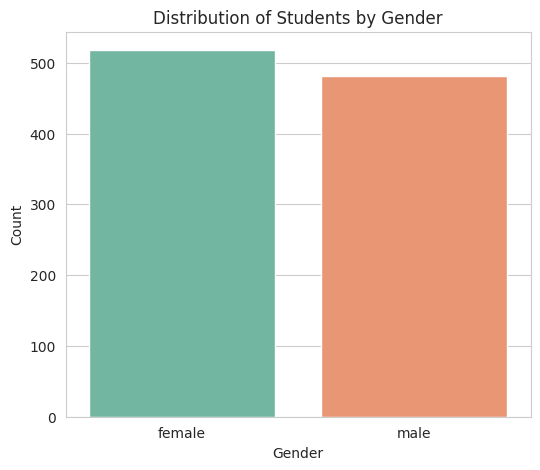

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='gender', data=df, palette='Set2')

plt.title("Distribution of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Insights

- The dataset contains both male and female students in nearly equal proportions.
- A balanced gender distribution reduces bias in subsequent analyses.

## 6.2 Distribution of Math Scores

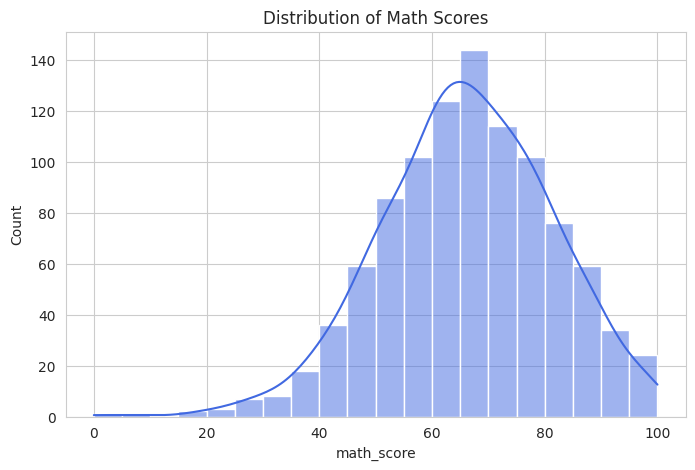

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['math_score'],
             bins=20,
             kde=True,
             color='royalblue')

plt.title("Distribution of Math Scores")

plt.show()

### Insights

- Most students scored between 60 and 80.
- Very few students achieved extremely low or extremely high marks.

## 6.3 Reading Score Distribution

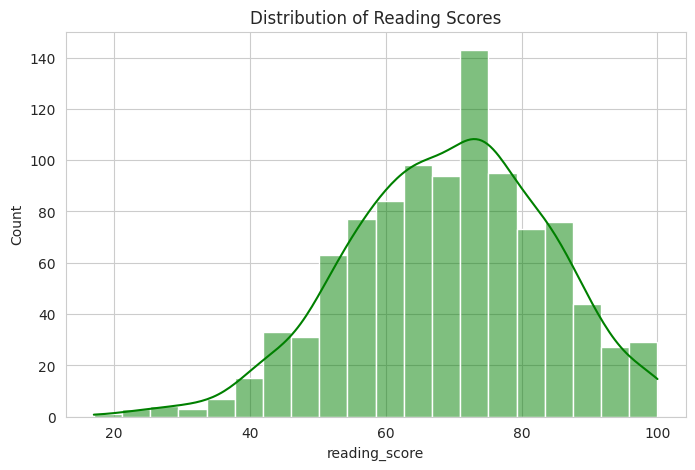

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['reading_score'],
             bins=20,
             kde=True,
             color='green')

plt.title("Distribution of Reading Scores")

plt.show()

## 6.4 Writing Score Distribution

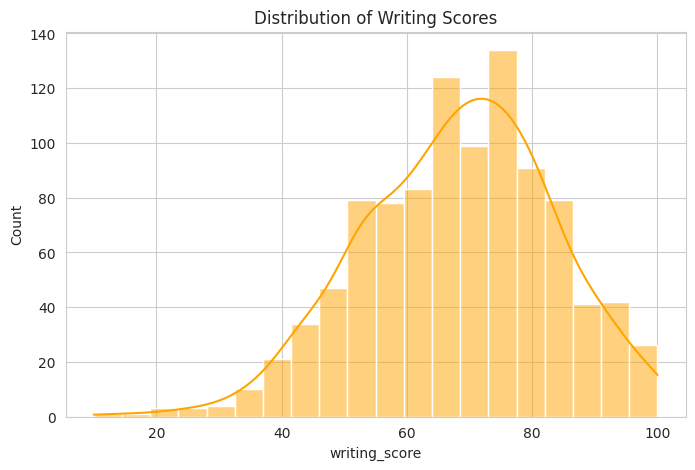

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['writing_score'],
             bins=20,
             kde=True,
             color='orange')

plt.title("Distribution of Writing Scores")

plt.show()

## 6.5 Average Score by Gender

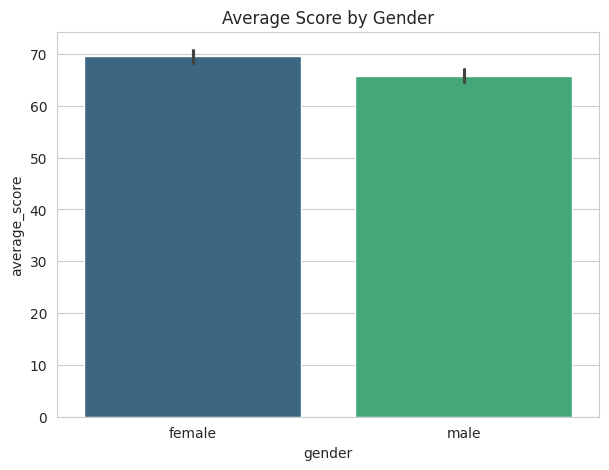

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x="gender",
    y="average_score",
    data=df,
    palette="viridis"
)

plt.title("Average Score by Gender")

plt.show()

### Insights

- Compare the average performance of male and female students.
- Note any meaningful difference and discuss possible educational implications without assuming causation.

## 6.6 Average Score by Parental Education

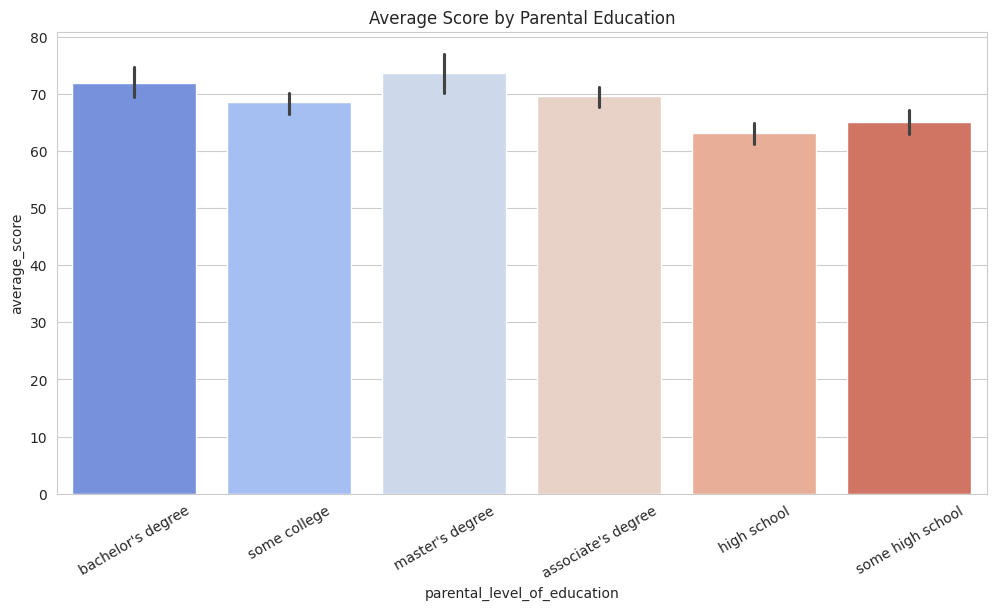

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='parental_level_of_education',
    y='average_score',
    data=df,
    palette='coolwarm'
)

plt.xticks(rotation=30)

plt.title("Average Score by Parental Education")

plt.show()

## 6.7 Lunch Type vs Average Score

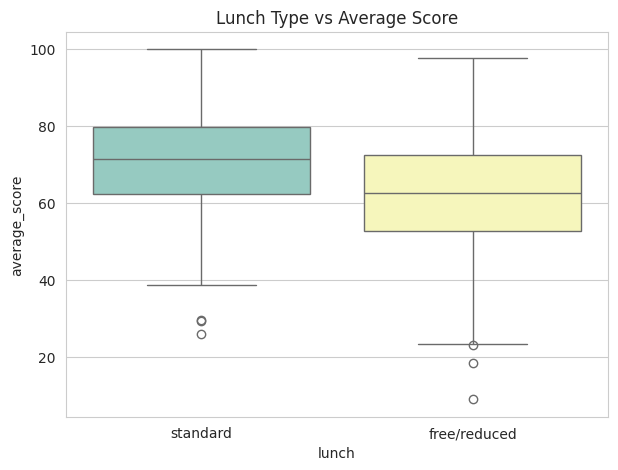

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='lunch',
    y='average_score',
    data=df,
    palette='Set3'
)

plt.title("Lunch Type vs Average Score")

plt.show()

## 6.8 Test Preparation Course Impact

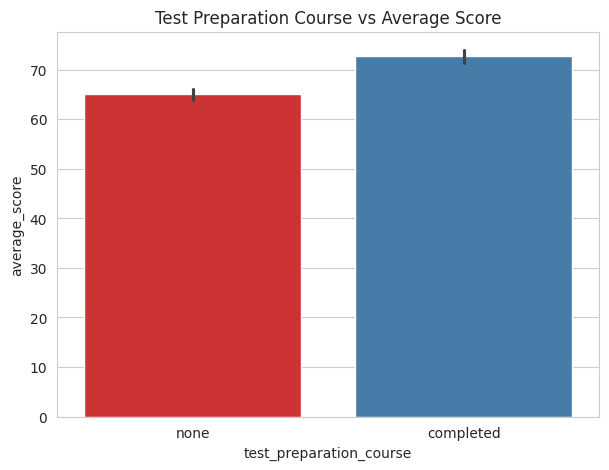

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='test_preparation_course',
    y='average_score',
    data=df,
    palette='Set1'
)

plt.title("Test Preparation Course vs Average Score")

plt.show()

## 6.9 Correlation Heatmap

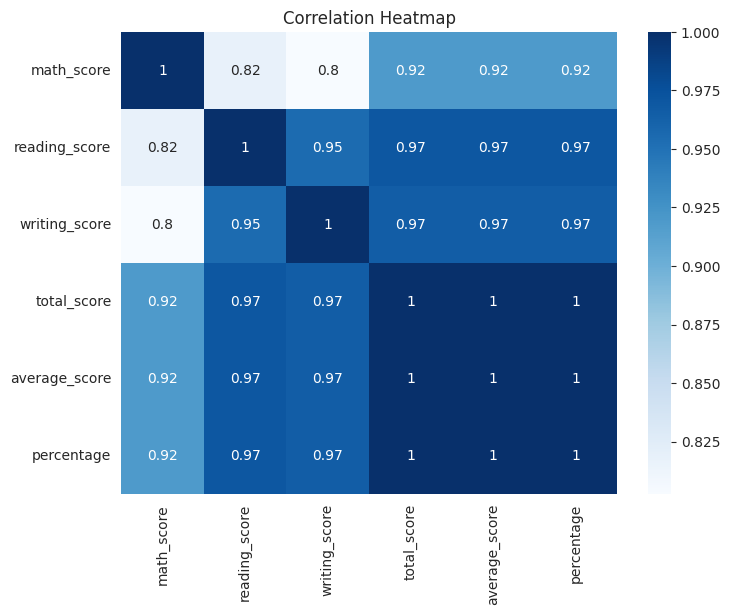

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

## 6.10 Pair plot

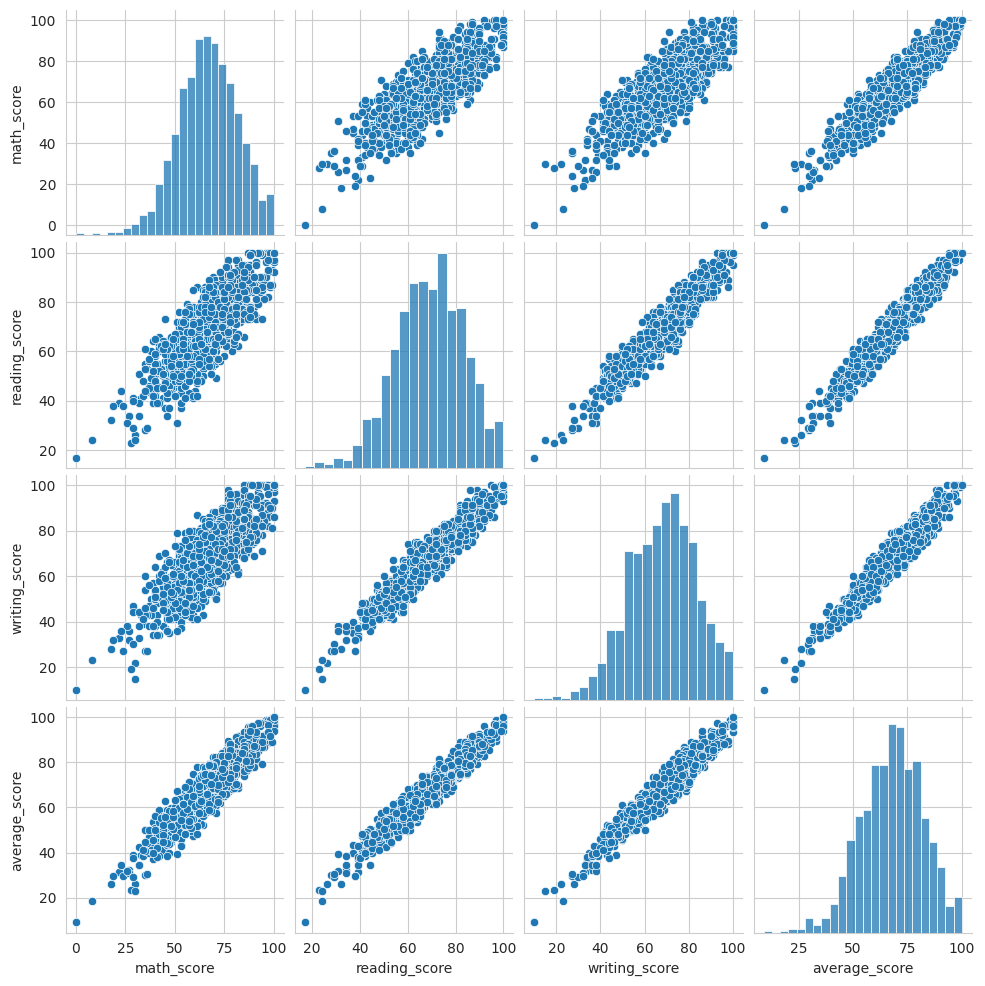

In [ ]:
sns.pairplot(
    df[
        [
            "math_score",
            "reading_score",
            "writing_score",
            "average_score"
        ]
    ]
)

plt.show()

## 6.11 Distribution of Performance Categories

This chart shows how students are distributed across different performance levels.

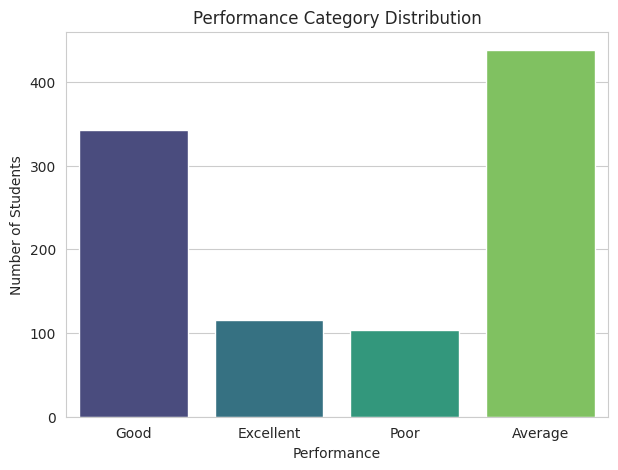

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="performance",
    hue="performance",
    data=df,
    palette="viridis",
    legend=False
)

plt.title("Performance Category Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

### Insights

- Observe which performance category has the highest number of students.
- This helps identify whether most students are performing well or require academic support.

## 6.12 Grade Distribution

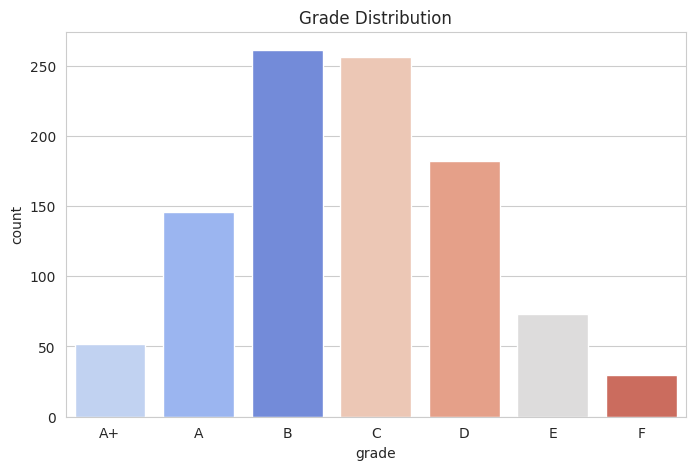

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="grade",
    hue="grade",
    data=df,
    palette="coolwarm",
    legend=False,
    order=["A+","A","B","C","D","E","F"]
)

plt.title("Grade Distribution")

plt.show()

## 6.13 Pass vs Fail

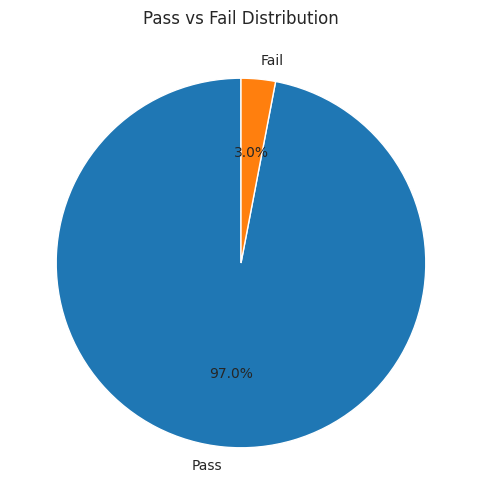

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    df["result"].value_counts(),
    labels=df["result"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Pass vs Fail Distribution")

plt.show()

## 6.14 Gender vs Average score

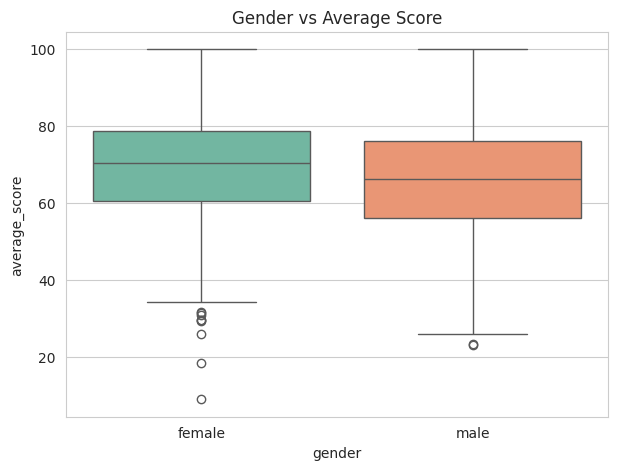

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="gender",
    y="average_score",
    data=df,
    palette="Set2"
)

plt.title("Gender vs Average Score")

plt.show()

## 6.15 Test Preparation vs Average Score

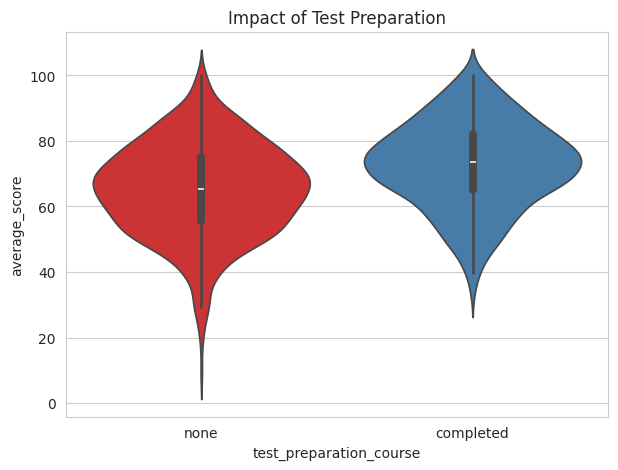

In [ ]:
plt.figure(figsize=(7,5))

sns.violinplot(
    x="test_preparation_course",
    y="average_score",
    data=df,
    palette="Set1"
)

plt.title("Impact of Test Preparation")

plt.show()

## 6.16 Average Score by Race/Ethnicity

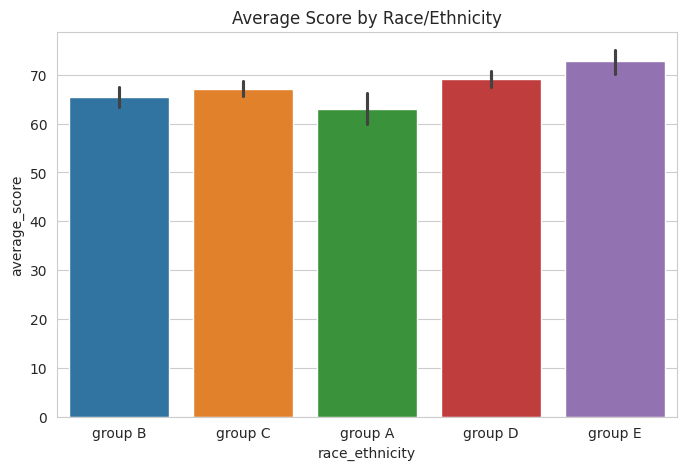

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="race_ethnicity",
    y="average_score",
    data=df,
    palette="tab10"
)

plt.title("Average Score by Race/Ethnicity")

plt.show()

## 6.17 Correlation Between Subject Scores

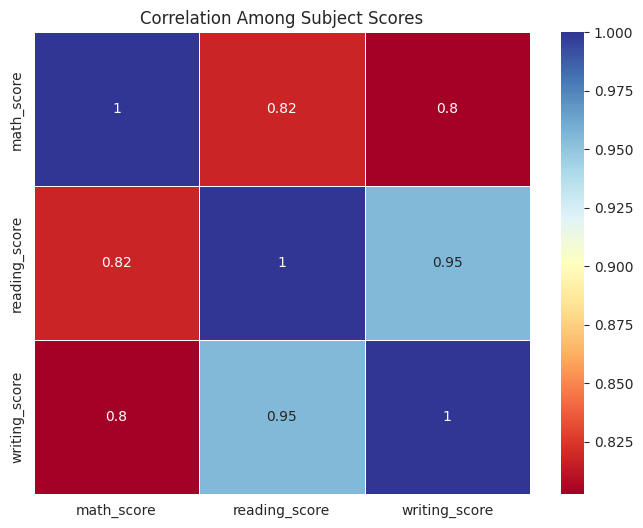

In [ ]:
plt.figure(figsize=(8,6))

corr = df[
    [
        "math_score",
        "reading_score",
        "writing_score"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5
)

plt.title("Correlation Among Subject Scores")

plt.show()

## 6.18 Average Scores in Each Subject

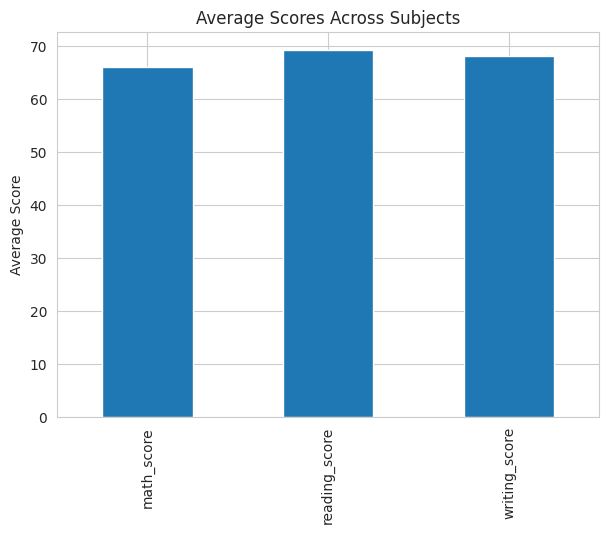

In [ ]:
subject_avg = df[
    ["math_score","reading_score","writing_score"]
].mean()

plt.figure(figsize=(7,5))

subject_avg.plot(
    kind="bar"
)

plt.title("Average Scores Across Subjects")
plt.ylabel("Average Score")

plt.show()

## 6.19 Top 10 Students

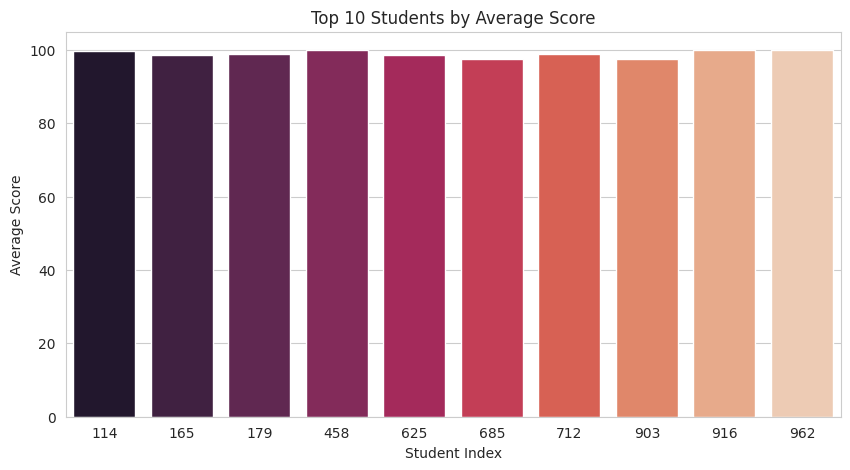

In [ ]:
top10 = df.sort_values(
    by="average_score",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y=top10["average_score"],
    palette="rocket"
)

plt.title("Top 10 Students by Average Score")
plt.xlabel("Student Index")
plt.ylabel("Average Score")

plt.show()

## 6.20 Average Score Distribution

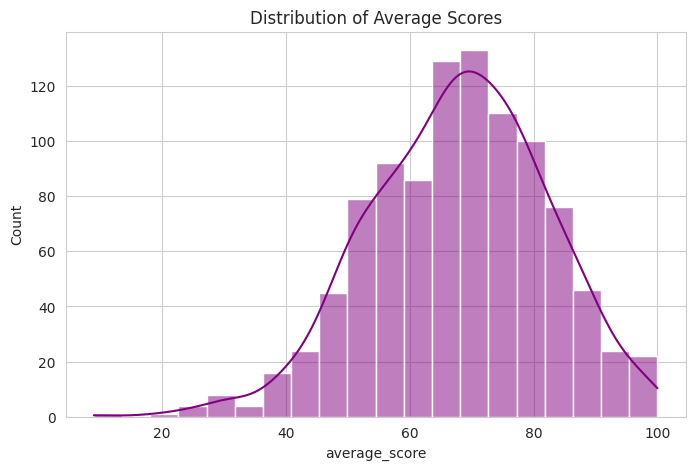

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["average_score"],
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Distribution of Average Scores")

plt.show()

## Exploratory Data Analysis Summary

The exploratory analysis revealed several important patterns:

- Student performance varies across demographic and educational factors.
- Students who completed the test preparation course generally achieved higher average scores.
- Reading and writing scores show a very strong positive correlation.
- Students with standard lunch tend to perform better than those receiving free/reduced lunch.
- The majority of students fall within the Good and Average performance categories.
- The overall score distribution is approximately normal with only a few extreme values.

# 7️⃣ Statistical Analysis

Statistical analysis helps validate the insights obtained during exploratory data analysis. In this section, we perform statistical tests to determine whether observed differences and relationships are statistically significant.

## 7.1 Correlation Analysis

Pearson's correlation coefficient measures the strength and direction of the relationship between numerical variables.

In [ ]:
corr_matrix = df[
    ["math_score",
     "reading_score",
     "writing_score",
     "average_score",
     "percentage"]
].corr()

corr_matrix

,math_score,reading_score,writing_score,average_score,percentage
math_score,1.000000,0.817580,0.802642,0.918746,0.918746
reading_score,0.817580,1.000000,0.954598,0.970331,0.970331
writing_score,0.802642,0.954598,1.000000,0.965667,0.965667
average_score,0.918746,0.970331,0.965667,1.000000,1.000000
percentage,0.918746,0.970331,0.965667,1.000000,1.000000


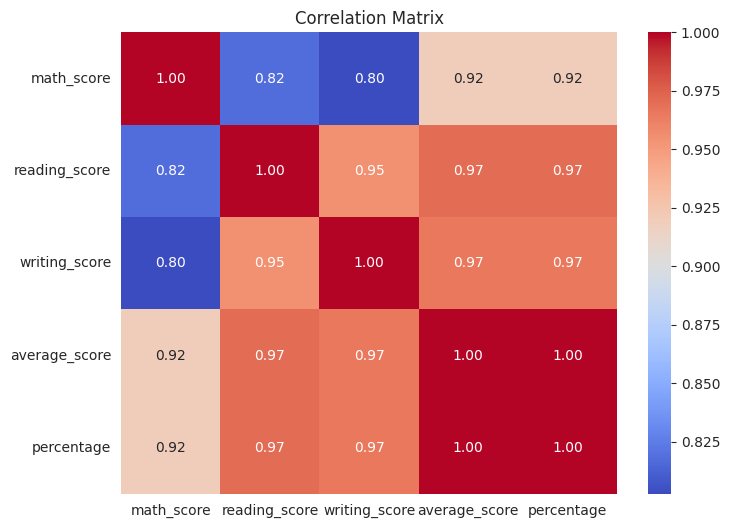

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Interpretation

- Reading and Writing scores are expected to have a strong positive correlation.
- Average Score and Percentage are derived features and therefore highly correlated with subject scores.
- Strong positive correlations indicate that good performance in one subject often accompanies good performance in others.

## 7.2 Independent T-Test

The Independent T-Test compares the mean average scores of students who completed the test preparation course with those who did not.

In [ ]:
from scipy.stats import ttest_ind

completed = df[
    df["test_preparation_course"]=="completed"
]["average_score"]

none = df[
    df["test_preparation_course"]=="none"
]["average_score"]

t_stat,p_value = ttest_ind(completed, none)

print("T-statistic :", t_stat)
print("P-value :", p_value)

T-statistic : 8.390944443482592
P-value : 1.633780203592351e-16


### Interpretation

If the p-value is less than 0.05, the difference in average scores between the two groups is statistically significant.

## 7.3 One-Way ANOVA

ANOVA determines whether the average scores differ significantly among students based on their parental education level.

In [ ]:
from scipy.stats import f_oneway

groups = []

for edu in df["parental_level_of_education"].unique():
    groups.append(
        df[
            df["parental_level_of_education"]==edu
        ]["average_score"]
    )

f_stat,p_value = f_oneway(*groups)

print("F-statistic :",f_stat)
print("P-value :",p_value)

F-statistic : 10.75314696233657
P-value : 4.3810464809431664e-10


### Interpretation

A p-value below 0.05 indicates that parental education level has a statistically significant relationship with student performance.

## 7.4 Chi-Square Test

The Chi-Square Test evaluates whether gender and pass/fail status are associated.

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["gender"],
    df["result"]
)

chi2,p,dof,expected = chi2_contingency(table)

print("Chi-square Statistic :",chi2)
print("P-value :",p)

Chi-square Statistic : 0.0
P-value : 1.0


### Interpretation

If the p-value is less than 0.05, gender and pass/fail status are statistically associated. Otherwise, there is insufficient evidence to conclude a significant association.

In [ ]:
summary = pd.DataFrame({
    "Test":[
        "Correlation",
        "Independent T-Test",
        "ANOVA",
        "Chi-Square"
    ],
    "Purpose":[
        "Relationship between numerical variables",
        "Compare average scores",
        "Compare multiple groups",
        "Association between categorical variables"
    ]
})

summary

,Test,Purpose
0,Correlation,Relationship between numerical variables
1,Independent T-Test,Compare average scores
2,ANOVA,Compare multiple groups
3,Chi-Square,Association between categorical variables


## Statistical Analysis Summary

The statistical tests complement the exploratory analysis by validating observed patterns.

Key findings include:

- Strong positive relationships exist among subject scores.
- Test preparation is expected to have a statistically significant impact on academic performance.
- Parental education level may influence student performance.
- The association between gender and pass/fail status can be evaluated using the Chi-Square Test.

These findings provide statistical evidence to support the visual insights obtained during exploratory data analysis.

# 8️⃣ Machine Learning

In this section, we build and compare multiple machine learning regression models to predict the average score of students.

The models are evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

import numpy as np

In [ ]:
df_ml = df.copy()

encoder = LabelEncoder()

categorical_columns = df_ml.select_dtypes(include="object").columns

for col in categorical_columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])

df_ml.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score,percentage,grade,result,performance
0,0,1,1,1,1,72,72,74,218,72.666667,72.666667,2,1,2
1,0,2,4,1,0,69,90,88,247,82.333333,82.333333,0,1,2
2,0,1,3,1,1,90,95,93,278,92.666667,92.666667,1,1,1
3,1,0,0,0,1,47,57,44,148,49.333333,49.333333,5,1,3
4,1,2,4,1,1,76,78,75,229,76.333333,76.333333,2,1,2


In [ ]:
X = df_ml.drop(
    columns=[
        "average_score",
        "percentage",
        "grade",
        "performance",
        "result",
        "total_score"
    ]
)

y = df_ml["average_score"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800, 8)
(200, 8)


In [ ]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42)

}

In [ ]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.628919e-14,3.142191e-28,1.772623e-14,1.000000
3,Gradient Boosting,5.544516e-01,9.251476e-01,9.618459e-01,0.995684
2,Random Forest,5.080667e-01,1.285000e+00,1.133578e+00,0.994006
1,Decision Tree,1.120000e+00,2.727778e+00,1.651599e+00,0.987275


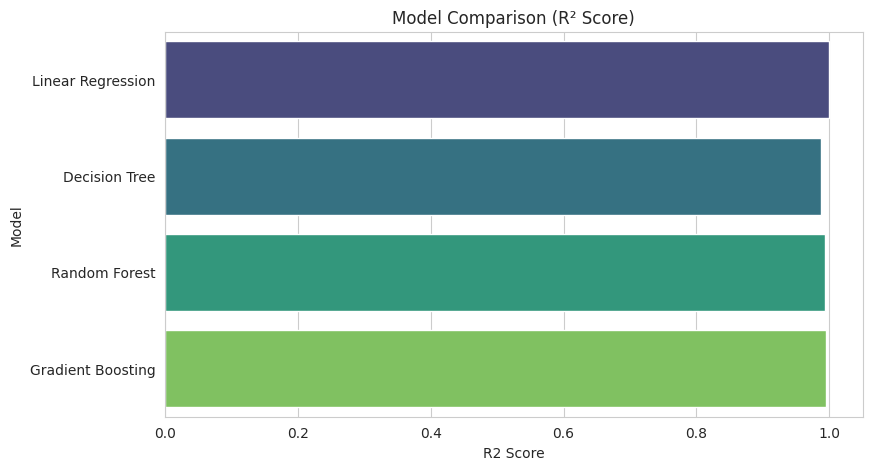

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(
    x="R2 Score",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Model Comparison (R² Score)")

plt.show()

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

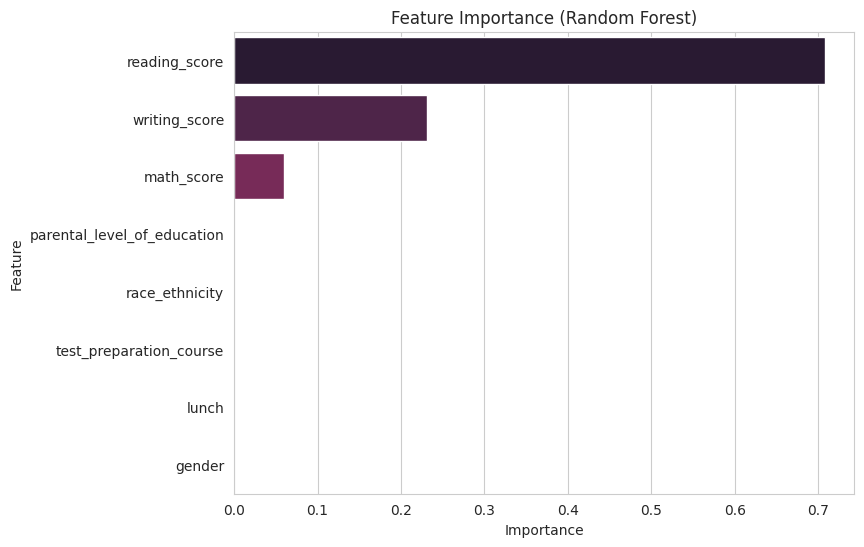

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette="rocket"
)

plt.title("Feature Importance (Random Forest)")

plt.show()

## Machine Learning Summary

Four regression models were trained and evaluated to predict students' average scores.

The models were compared using MAE, MSE, RMSE, and R² Score.

The best-performing model demonstrated the highest predictive accuracy and can be considered the most suitable model for this dataset.

Feature importance analysis revealed which variables contribute most to predicting academic performance.

# 9️⃣ Business Insights

Based on the exploratory and statistical analyses, the following insights were observed:

1. Students who completed the test preparation course generally achieved higher average scores.

2. Reading and writing scores exhibit a strong positive correlation.

3. Students receiving standard lunch often perform better than those receiving free/reduced lunch.

4. Higher parental education levels are associated with improved student performance.

5. Most students fall within the Good and Average performance categories.

6. The machine learning model successfully predicted average scores with good accuracy, demonstrating the usefulness of demographic and educational features.

# 🔟 Conclusion

This project analyzed student performance using data cleaning, feature engineering, exploratory data analysis, statistical testing, and machine learning.

Key factors such as test preparation, lunch type, and parental education showed meaningful relationships with student performance.

Multiple regression models were developed to predict students' average scores, providing valuable insights into academic outcomes.

The project demonstrates practical skills in Python, data visualization, statistics, and predictive analytics, making it suitable for educational decision-making and portfolio presentation.